In [1]:
# This cells setups the environment when executed in Google Colab.
try:
    import google.colab
    !curl -s https://raw.githubusercontent.com/ibs-lab/cedalion/dev/scripts/colab_setup.py -o colab_setup.py
    # Select branch with --branch "branch name" (default is "dev")
    %run colab_setup.py
except ImportError:
    pass

In [2]:
import cedalion
import cedalion.sigproc.quality as quality
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import xarray as xr
from cedalion import units
import cedalion.data

# MATLAB Engine API for Python

The MATLAB Engine provides a framework that allows users to call MATLAB functions and commands directly from Python code. This can be especially useful when certain functions or parts of a processing pipeline are only available in MATLAB.

To use the MATLAB Engine in Python, you must ensure that an active MATLAB license is accessible and that your Python version is supported by your MATLAB release. Detailed information about installing the MATLAB Engine and checking version compatibility can be found here: [Install MATLAB Engine API for Python](https://www.mathworks.com/help/matlab/matlab_external/install-the-matlab-engine-for-python.html)

In [3]:
# import and start the MATLAB engine
import matlab.engine 
eng = matlab.engine.start_matlab()

In [4]:
# We can now call built-in MATLAB functions directly from Python
A = eng.magic(4)
det_A = eng.det(A)

print('A =', A,)
print('det(A) =', det_A)

# Ask for type in MATLAB 
print("MATLAB data type:", eng.feval("class", A))

A = [[16.0,2.0,3.0,13.0],[5.0,11.0,10.0,8.0],[9.0,7.0,6.0,12.0],[4.0,14.0,15.0,1.0]]
det(A) = -1.4495071809506048e-12
MATLAB data type: double


## Configuring the MATLAB Search Path

When calling MATLAB functions from Python, keep in mind that Python and MATLAB maintain separate search paths and working directories. A MATLAB function must either be located in the MATLAB Engine session’s current folder or be available on the MATLAB search path. You can add the folder containing your MATLAB functions to the search path using `eng.addpath()` , as explained in [the MathWorks documentation](https://www.mathworks.com/help/matlab/matlab_external/call-user-script-and-function-from-python.html).

# MATLAB-Based Source Decomposition in a Cedalion Pipeline 
In the following example, we demonstrate how a constrained [Independent Component Analysis (ICA)](https://en.wikipedia.org/wiki/Independent_component_analysis) method implemented in MATLAB can be applied within an fNIRS processing pipeline in Cedalion. We load and process a resting-state fNIRS dataset together with auxiliary photoplethysmography (PPG), respiration, and mean arterial pressure (MAP) recordings. After preparing the resting-state and auxiliary data, we convert the data from NumPy arrays to MATLAB arrays, apply the constrained ICA method MOO-ICAR using the MATLAB Engine, and convert the returned MATLAB arrays back to NumPy arrays. To skip the preprocessing steps, jump directly to [Applying MOO-ICAR Using the MATLAB Engine](#use-the-matlab-engine-to-apply-moo-icar). 


### Multi-Objective Optimization ICA with Reference (MOO-ICAR)
[MOO-ICAR](https://www.sciencedirect.com/science/article/abs/pii/S1053811912011044) (also known as ICA-R) is a constrained ICA method based on multi-objective optimization that incorporates reference information. It was originally proposed for group ICA (GIG-ICA) of fMRI data. In MOO-ICAR, source separation is performed by maximizing negentropy while simultaneously imposing a Pearson correlation constraint to incorporate the reference information. As a step in group ICA, MOO-ICAR is typically used to extract corresponding independent components across multiple subjects. In contrast to most ICA methods, which separate an entire dataset into multiple sources, MOO-ICAR extracts only the component associated with the specified reference. Its application to single-subject data is therefore not its intended use. Nevertheless, we apply it in this manner here to provide a simple example of using the MATLAB Engine.


## Loading Resting-State fNIRS Data

We load the resting-state fNIRS data, including the auxiliary physiological measurements from the SNIRF file. For the demixing problem, we use middle-distance channels of approximately 15 mm in length to ensure that physiological noise signals are present in the data.

In [5]:
# Load data
rec = cedalion.data.get_spa_fnirs()
    
# Read fnirs data 
fnirs_amp = rec['amp']

# Define middle distance channels 
middle_channels = ['S1D7', 'S1D8', 'S1D13', 'S1D14', 'S1D15', 'S1D16', 'S2D8', 'S2D11', 'S2D12', 
                   'S3D7', 'S3D9', 'S3D10', 'S4D1', 'S4D5', 'S4D10', 'S4D16', 'S5D4', 'S5D5', 'S5D11', 
                   'S5D15', 'S6D3', 'S6D6', 'S6D12', 'S6D14', 'S7D2', 'S7D6', 'S7D9', 'S7D13', 'S8D22', 
                   'S8D23', 'S8D24', 'S8D29', 'S8D30', 'S8D31', 'S9D24', 'S9D27', 'S9D28', 'S10D23', 'S10D25',
                   'S10D26', 'S11D19', 'S11D26', 'S11D31', 'S12D18', 'S12D19', 'S12D22', 'S12D28', 'S13D17', 
                   'S13D20', 'S13D27', 'S13D29', 'S14D20', 'S14D21', 'S14D25', 'S14D30']


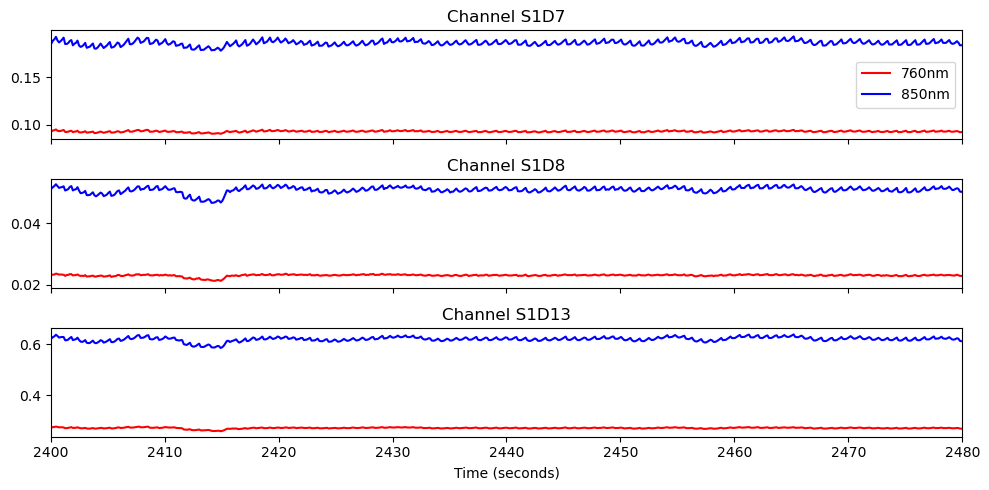

In [6]:
# Plot three middle distance channels
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 5))
for i, ch in enumerate(['S1D7', 'S1D8', 'S1D13']):
    ax[i].plot(fnirs_amp.time, fnirs_amp.sel(channel=ch, wavelength="760"), "r-", label="760nm")
    ax[i].plot(fnirs_amp.time, fnirs_amp.sel(channel=ch, wavelength="850"), "b-", label="850nm")
    ax[i].set_title(f"Channel {ch}")

ax[0].legend()
ax[2].set_xlim(2400,2480)
ax[2].set_xlabel("Time (seconds)")
plt.tight_layout()

## Conversion to Optical Density

In [7]:
# Convert to OD
fnirs_od = cedalion.nirs.cw.int2od(fnirs_amp)

## Select Resting-State Session

Our data contain a resting-state session of 75 seconds. We select this session and crop the first 10 seconds to remove non-stationarities in the data. From the remaining session, we select a 60-second interval for our analysis using the middle-distance channels.

In [8]:
# Select the onset of the resting state interval (pre_sitting) 
onset_resting = rec.stim[rec.stim.trial_type == 'pre_sitting'].onset.values[0]

# We cropp the first 10 seconds of the resting state interval to 
# avoid transient effects and select a 60 second interval for the analysis.
interval = [onset_resting + 10, onset_resting + 70]

# Select interval and channels 
interval_fnirs_od = fnirs_od.sel(time=slice(interval[0], interval[1]))
interval_fnirs_od = interval_fnirs_od.sel(channel= middle_channels)

## Channel Quality Assessment and Pruning

We compute the Scalp Coupling Index (SCI) and Peak Spectral Power (PSP) for channel quality assessment. SCI and PSP are computed for each channel, and we then select the 40 channels with the highest percentage of clean time.

In [9]:
# Define parameters for quality metrics
window_length = 5 * units.s
sci_thresh = 0.75
psp_thresh = 0.1
sci_psp_percentage_thresh = 0.75

# Compute SCI and PSP 
sci, sci_mask = quality.sci(interval_fnirs_od, window_length, sci_thresh)
psp, psp_mask = quality.psp(interval_fnirs_od, window_length, psp_thresh)
sci_x_psp_mask = sci_mask & psp_mask
perc_time_clean = sci_x_psp_mask.sum(dim="time") / len(sci.time)

# Set the number of channels to include in the ICA analysis
num_ch = 40

# Select the best channels 
id_best_channels = np.argsort(perc_time_clean)[-num_ch:]
best_channels = id_best_channels['channel']
best_middle_channels = interval_fnirs_od.sel(channel=best_channels)

## Convert Optical Density to Concentration Changes 

In [10]:
#  Convert optical density to concentration changes 
montage = rec.geo3d
dpf = xr.DataArray(
    [6, 6],
    dims="wavelength",
    coords={"wavelength": fnirs_od.wavelength},)
    
fnirs_con = cedalion.nirs.cw.od2conc(fnirs_od, montage, dpf)

## High-Pass Filtering and Selection of HbO

In [11]:
# Apply high-pass filter
y_filt = fnirs_con.cd.freq_filter(fmin= 0.01, fmax= 0, butter_order=4)

# Select resting state interval
y_filt = y_filt.sel(time = slice(interval[0], interval[1]))

# Select middle distance channels
y_filt = y_filt.sel(channel=best_middle_channels.channel.values)

# Select only HbO signal 
y_filt = y_filt.sel(chromo = 'HbO')

# Turn to numpy array 
data = y_filt.values

# z-transform the data
data = sp.stats.zscore(data, axis=1) 

/opt/miniconda3/envs/cedalion/lib/python3.11/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Prepare the Auxiliary Signals

We now extract the respiration ('Resp'), PPG ('Pleth'), or mean arterial pressure ('MAP') signals from the recording. These signals must be downsampled to match the fNIRS sampling frequency. We first select the resting-state interval with an additional buffer and apply a band-pass filter to the data to avoid aliasing effects. The MAP signal may contain missing samples, which we address using an interpolation step.

In [12]:

# Select the auxiliary signal from the recording 
aux_name = 'MAP' # use 'MAP', 'Pleth' or 'Resp' 
aux_signal = rec.aux_ts[aux_name]

# Select the interval of the auxiliary signal with a 100 second buffer 
# before and after the resting state interval to avoid edge effects in the filtering step
buffer = 100 
aux_signal = aux_signal.sel(time = slice(interval[0]- buffer, interval[1] + buffer ))

# Add a new coordinate called samples and add unit 
aux_signal['time'].attrs['units'] = 'seconds'
samples = np.arange(aux_signal.sizes['time'])
aux_signal = aux_signal.assign_coords(samples=('time', samples))

# Fix missing samples in the MAP signal 
if aux_name == 'MAP':
    aux_signal = aux_signal.interpolate_na(dim = 'time' ,method = 'cubic',
                                               fill_value='extrapolate')

# Apply bandpass filter to the auxiliary signal to avaoid aliasing effects after the downsampling step.
aux_signal = aux_signal.cd.freq_filter(fmin= 0.01, fmax= 2.5 , butter_order=4) 

# Downsample the auxiliary signal by interpolating it to the time points of the fNIRS signal
time_line = fnirs_con.sel(time = slice(interval[0]- buffer,interval[1]+buffer))
aux_signal = aux_signal.drop_duplicates(dim='time')
aux_signal = aux_signal.interp(time=time_line.time)
aux_signal = aux_signal.dropna(dim="time", how="any")

# Remove buffer 
aux_signal = aux_signal.sel(time = slice(interval[0], interval[1]))

# Turn to numpy array and reshape 
aux_signal = np.array(aux_signal.values, dtype=np.float64).T
aux_signal = aux_signal.reshape(1, -1)  


# z-transform the data and auxiliary signal
data = sp.stats.zscore(data, axis=1) 
aux_signal = sp.stats.zscore(aux_signal, axis=1)

/opt/miniconda3/envs/cedalion/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2622: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)


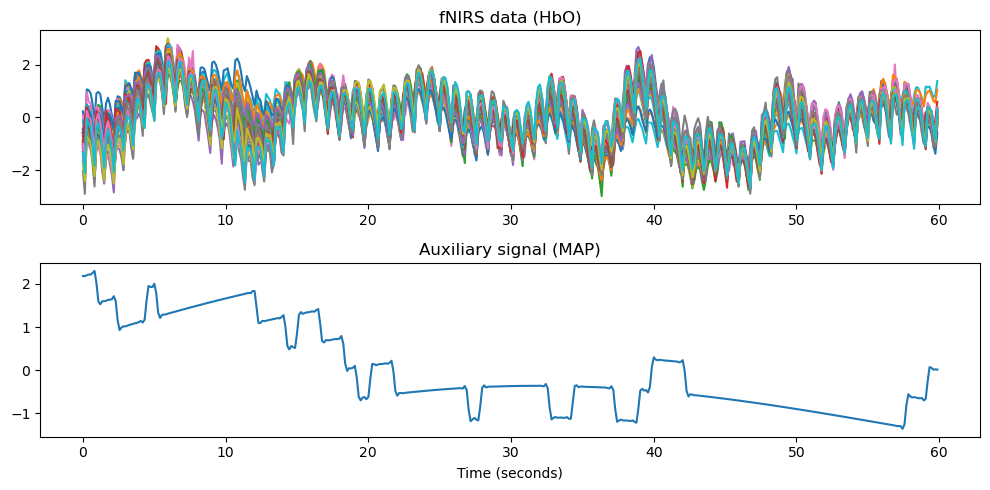

In [13]:
# Plot the data and the auxiliary signal
fig, ax = plt.subplots(2, 1, figsize=(10, 5))

x_time = np.arange(data.shape[1]) * 1/(7.4)
ax[0].plot(x_time, data.T)
ax[0].set_title('fNIRS data (HbO)')
ax[1].plot(x_time, aux_signal[0])
ax[1].set_title(f'Auxiliary signal ({aux_name})')
ax[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()


## Use the MATLAB Engine to Apply MOO-ICAR

We have prepared the data and reference signals. Next, we convert both to MATLAB arrays and apply constrained ICA. MOO-ICAR takes the data and reference signals as inputs and returns the separated component corresponding to the reference, along with its associated mixing vector. Finally, we convert the component back to a NumPy array.

In [14]:
# Ensure compatibility with MATLAB default double-precision format by converting
# the data and reference signal to contiguous Numpy float64 arrays.
data = np.ascontiguousarray(data, dtype=np.float64)
ref = np.ascontiguousarray(aux_signal, dtype=np.float64)

# Convert the data and reference signal to MATLAB arrays.
data_matlab = matlab.double(data)
ref_matlab = matlab.double(ref)

# Call the MATLAB function for MOO-ICAR through the MATLAB Engine.
# To receive multiple outputs from a MATLAB function in Python, specify nargout=2.
component, M = eng.icatb_gigicar(data_matlab, ref_matlab, nargout=2)

# Convert the MATLAB array to a Numpy array.
component = np.array(component)

## Plot Extracted Component

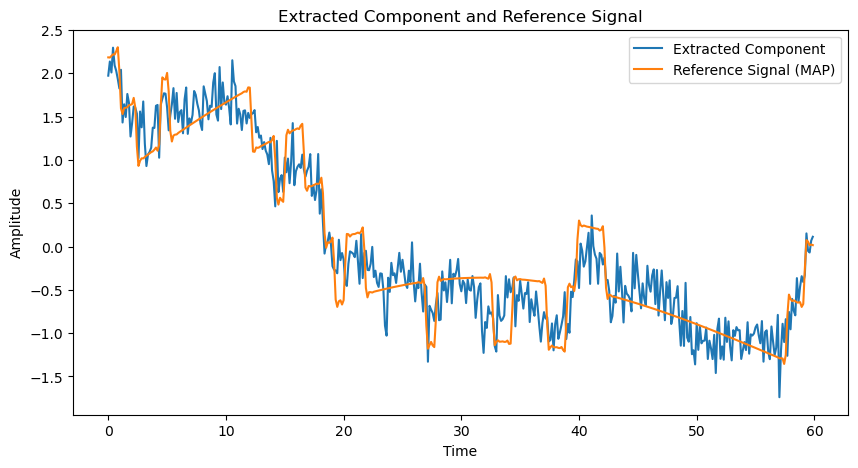

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(x_time, component[0], label='Extracted Component')
plt.plot(x_time, ref[0], label=f'Reference Signal ({aux_name})')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Extracted Component and Reference Signal')
plt.legend()
plt.show()

## References

In [16]:
cedalion.bib.dump_to_notebook()

[1],Tucker2022,cedalion.io.snirf.read_snirf,"Stephen Tucker, Jay Dubb, Sreekanth Kura, Alexander von Lühmann, Robert Franke, Jörn M. Horschig, Samuel Powell, Robert Oostenveld, Michael Lührs, Édouard Delaire, Zahra M. Aghajan, Hanseok Yun, Meryem A. Yücel, Qianqian Fang, Theodore J. Huppert, Blaise deB. Frederick, Luca Pollonini, David A. Boas, and Robert Luke. Introduction to the shared near infrared spectroscopy format. Neurophotonics, 10(1):013507, 2022. doi:10.1117/1.NPh.10.1.013507."
[2],Delpy1988,"cedalion.nirs.cw.int2od, cedalion.nirs.cw.od2conc","D. T. Delpy, M. Cope, P. van der Zee, S. Arridge, S. Wray, and J. Wyatt. Estimation of optical pathlength through tissue from direct time of flight measurement. Physics in Medicine and Biology, 33(12):1433–1442, 1988. doi:10.1088/0031-9155/33/12/008."
[3],Villringer1997,"cedalion.nirs.cw.int2od, cedalion.nirs.cw.od2conc","Arno Villringer and Britton Chance. Non-invasive optical spectroscopy and imaging of human brain function. Trends in Neurosciences, 20(10):435–442, 1997. doi:10.1016/S0166-2236(97)01132-6."
[4],Pollonini2014,"cedalion.sigproc.quality.psp, cedalion.sigproc.quality.sci","Luca Pollonini, Cristen Olds, Homer Abaya, Heather Bortfeld, Michael S. Beauchamp, and John S. Oghalai. Auditory cortex activation to natural speech and simulated cochlear implant speech measured with functional near-infrared spectroscopy. Hearing Research, 309:84–93, 2014. doi:https://doi.org/10.1016/j.heares.2013.11.007."
[5],Pollonini2016,"cedalion.sigproc.quality.psp, cedalion.sigproc.quality.sci","Luca Pollonini, Heather Bortfeld, and John S. Oghalai. PHOEBE: a method for real time mapping of optodes-scalp coupling in functional near-infrared spectroscopy. Biomedical Optics Express, 7(12):5104, Dec 2016. doi:10.1364/BOE.7.005104."
[6],Prahl1998,cedalion.nirs.common.get_extinction_coefficients,"Scott A. Prahl. Optical absorption of hemoglobin. Oregon Medical Laser Center, online resource, 1998. URL: https://omlc.org/spectra/hemoglobin/."
